<a href="https://colab.research.google.com/github/Mansehaj-Singh/Drone-Orientation-Estimation/blob/main/Mansehaj_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading dataset: fast_v4.mat...
Starting Training...
Epoch 10/50 | Loss: 0.000823
Epoch 20/50 | Loss: 0.000300
Epoch 30/50 | Loss: 0.000136
Epoch 40/50 | Loss: 0.000082
Epoch 50/50 | Loss: 0.000067

Starting Evaluation...
------------------------------
TEST RESULTS
------------------------------
Orientation RMSE (Deg): 0.9330°
Mean Angular Error (Deg): 0.7392°
Max Error (Deg): 3.1305°
------------------------------


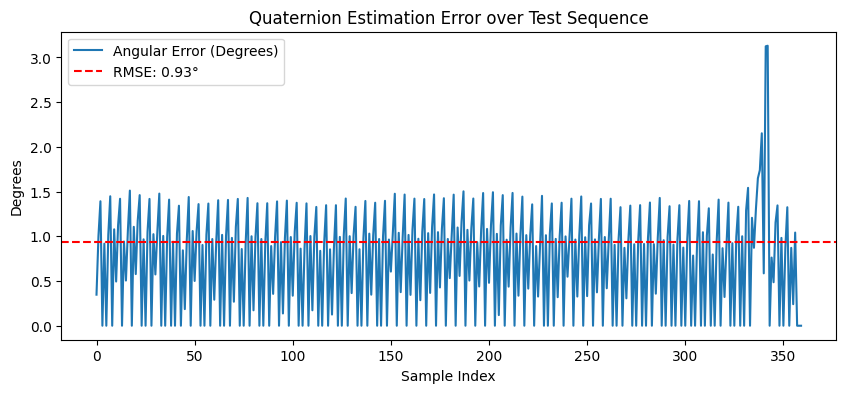

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# 1. Configuration & Hyperparameters

class Config:
    FILE_PATH = 'fast_v4.mat'

    COL_ACC = slice(1, 4)
    COL_GYRO = slice(4, 7)
    COL_MAG = slice(7, 10)
    COL_GT_Q = slice(10, 14)

    WINDOW_SIZE = 200
    STRIDE = 10
    BATCH_SIZE = 64
    LEARNING_RATE = 1e-4
    EPOCHS = 50
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# 2. Dataset Logic

class DroneIMUDataset(Dataset):
    def __init__(self, data_array):
        self.acc = data_array[:, Config.COL_ACC]
        self.gyro = data_array[:, Config.COL_GYRO]
        self.mag = data_array[:, Config.COL_MAG]
        self.gt_q = data_array[:, Config.COL_GT_Q]

        self.indices = list(range(0, len(data_array) - Config.WINDOW_SIZE, Config.STRIDE))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        end = start + Config.WINDOW_SIZE

        # 9-Axis extraction
        acc_win = self.acc[start:end]
        gyro_win = self.gyro[start:end]
        mag_win = self.mag[start:end]

        # Gravity & Inclination for Pose-TuningNet
        grav = np.tile(np.mean(acc_win, axis=0), (Config.WINDOW_SIZE, 1))
        lin_acc = acc_win - grav

        roll = np.arctan2(grav[:, 1], grav[:, 2])
        pitch = np.arctan2(-grav[:, 0], np.sqrt(grav[:, 1]**2 + grav[:, 2]**2))
        inclination = np.stack([roll, pitch], axis=1)

        return {
            'lin_acc': torch.FloatTensor(lin_acc).T,
            'gyro': torch.FloatTensor(gyro_win).T,
            'mag': torch.FloatTensor(mag_win).T,
            'grav': torch.FloatTensor(grav).T,
            'inclination': torch.FloatTensor(inclination).T,
            'gt_q': torch.FloatTensor(self.gt_q[end-1])
        }


# 3. Network Architecture (Extended IONet)

class Encoder(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(3)
        )
    def forward(self, x): return self.net(x)

class ExtendedIONet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_acc = Encoder(3)
        self.enc_gyro = Encoder(3)
        self.enc_mag = Encoder(3)
        self.enc_grav = Encoder(3)
        self.enc_tune = Encoder(2)

        self.lstm1 = nn.LSTM(128*5, 128, bidirectional=True, batch_first=True)
        self.lstm2 = nn.LSTM(256, 128, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(256, 4)

    def forward(self, batch):
        f_acc = self.enc_acc(batch['lin_acc'])
        f_gyro = self.enc_gyro(batch['gyro'])
        f_mag = self.enc_mag(batch['mag'])
        f_grav = self.enc_grav(batch['grav'])
        f_tune = self.enc_tune(batch['inclination'])

        combined = torch.cat([f_acc, f_gyro, f_mag, f_grav, f_tune], dim=1).transpose(1, 2)
        x, _ = self.lstm1(combined)
        x, _ = self.lstm2(x)

        q = self.fc(x[:, -1, :])
        return F.normalize(q, p=2, dim=1)

# 4. Training and Evaluation Routine

def run_pipeline():
    print(f"Loading dataset: {Config.FILE_PATH}...")
    mat = scipy.io.loadmat(Config.FILE_PATH)
    # Automatically find the data key (usually 'fast' or 'XS1', etc.)
    data_key = [k for k in mat.keys() if not k.startswith('__')][0]
    raw_data = mat[data_key]

    # Split Data
    train_data, test_data = train_test_split(raw_data, test_size=0.2, shuffle=False)

    train_loader = DataLoader(DroneIMUDataset(train_data), batch_size=Config.BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(DroneIMUDataset(test_data), batch_size=1, shuffle=False)

    model = ExtendedIONet().to(Config.DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)

    # Loss: 1 - |q_pred · q_gt| (Orientation similarity)
    def orientation_loss(p, g):
        return 1 - torch.mean(torch.abs(torch.sum(p * g, dim=1)))

    print("Starting Training...")
    model.train()
    for epoch in range(1, Config.EPOCHS + 1):
        epoch_loss = 0
        for b in train_loader:
            b = {k: v.to(Config.DEVICE) for k, v in b.items()}
            optimizer.zero_grad()
            pred = model(b)
            loss = orientation_loss(pred, b['gt_q'])
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        if epoch % 10 == 0:
            print(f"Epoch {epoch}/{Config.EPOCHS} | Loss: {epoch_loss/len(train_loader):.6f}")


    # 5. Testing & Metrics

    print("\nStarting Evaluation...")
    model.eval()
    angular_errors = []

    with torch.no_grad():
        for b in test_loader:
            b = {k: v.to(Config.DEVICE) for k, v in b.items()}
            pred = model(b)
            gt = b['gt_q']

            # Distance: 2 * acos(|q1 . q2|)
            dot = torch.clamp(torch.abs(torch.sum(pred * gt)), -1.0, 1.0)
            angle_error_rad = 2 * torch.acos(dot)
            angular_errors.append(angle_error_rad.item())

    errors_np = np.array(angular_errors)
    rmse_rad = np.sqrt(np.mean(errors_np**2))
    rmse_deg = np.degrees(rmse_rad)
    mean_deg = np.degrees(np.mean(errors_np))

    print("-" * 30)
    print(f"TEST RESULTS")
    print("-" * 30)
    print(f"Orientation RMSE (Deg): {rmse_deg:.4f}°")
    print(f"Mean Angular Error (Deg): {mean_deg:.4f}°")
    print(f"Max Error (Deg): {np.degrees(np.max(errors_np)):.4f}°")
    print("-" * 30)

    # Simple plot of errors
    plt.figure(figsize=(10, 4))
    plt.plot(np.degrees(angular_errors), label='Angular Error (Degrees)')
    plt.axhline(y=rmse_deg, color='r', linestyle='--', label=f'RMSE: {rmse_deg:.2f}°')
    plt.title("Quaternion Estimation Error over Test Sequence")
    plt.xlabel("Sample Index")
    plt.ylabel("Degrees")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    run_pipeline()